In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy.special as special

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 10,
    "legend.fontsize": 12
})

import pickle
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

In [2]:
def simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, rng=None):
    """Run one replicate of the adaptive-network SIR model.

    Parameters
    ----------
    beta : float in [0, 1]
        Transmission probability. At each time step, each S-I edge
        transmits the infection independently with probability beta.
        Higher beta means the disease spreads faster.
    gamma : float in [0, 1]
        Recovery probability. At each time step, each infected node
        recovers independently with probability gamma.
        Higher gamma means shorter infectious period (on average 1/gamma steps).
    rho : float in [0, 1]
        Rewiring probability. At each time step, each S-I edge is
        rewired independently with probability rho. The susceptible
        node drops the link to its infected neighbor and connects to
        a randomly chosen new node instead.
        Higher rho means more active social distancing behavior.
    N : int, default=200
        Number of nodes (individuals) in the network.
    p_edge : float, default=0.05
        Probability of an edge between any two nodes in the initial
        Erdos-Renyi random graph. Expected initial degree is (N-1)*p_edge.
        With N=200 and p_edge=0.05, the expected degree is about 10.
    n_infected0 : int, default=5
        Number of nodes infected at time t=0. These are chosen
        uniformly at random (without replacement) from all N nodes.
    T : int, default=200
        Number of discrete time steps to simulate.
    rng : numpy.random.Generator or None
        Random number generator for reproducibility. If None, a new
        generator is created with an arbitrary seed. Pass
        np.random.default_rng(seed) for reproducible runs.

    Returns
    -------
    infected_fraction : np.ndarray, shape (T+1,)
        Fraction of the population that is infected at each time step,
        from t=0 to t=T. Values are in [0, 1].
    rewire_counts : np.ndarray, shape (T+1,)
        Number of successful rewiring events at each time step.
        Always 0 at t=0 (no rewiring before the simulation starts).
    degree_histogram : np.ndarray, shape (31,)
        Histogram of node degrees at the final time step t=T.
        degree_histogram[d] = number of nodes with degree d, for d=0..29.
        degree_histogram[30] counts all nodes with degree >= 30.
    """

    """
    Adaptive-network SIR epidemic simulator.

    This module simulates an SIR (Susceptible-Infected-Recovered) epidemic
    spreading on a network that evolves over time. The key idea is that
    susceptible individuals can "rewire" their connections to avoid infected
    neighbors, which couples the disease dynamics with the network topology.

    The model proceeds in discrete time steps, each with three phases:
    1. Infection: infected nodes transmit the disease to susceptible neighbors
    2. Recovery: infected nodes recover (and become immune)
    3. Rewiring: susceptible nodes break links with infected neighbors and
        form new connections elsewhere

    Reference: Gross et al. (2006), "Epidemic dynamics on an adaptive network",
    Physical Review Letters, 96(20), 208701.
    """

    if rng is None:
        rng = np.random.default_rng()

    # =====================================================================
    # STEP 0: Build the initial contact network as an Erdos-Renyi graph.
    #
    # We represent the network as an adjacency list using Python sets.
    # neighbors[i] is the set of node indices connected to node i.
    # Sets allow O(1) lookups for "is j a neighbor of i?" and efficient
    # add/remove operations, which is important for the rewiring step.
    #
    # For each pair (i, j) with i < j, we add an edge with probability
    # p_edge. This produces an undirected graph (if i is connected to j,
    # then j is also connected to i).
    # =====================================================================
    neighbors = [set() for _ in range(N)]
    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() < p_edge:
                neighbors[i].add(j)
                neighbors[j].add(i)

    # =====================================================================
    # Initialize the health state of each node.
    #
    # We encode states as integers:
    #   0 = Susceptible (S): can catch the disease
    #   1 = Infected (I):    currently infectious
    #   2 = Recovered (R):   immune, cannot be infected again
    #
    # At t=0, we pick n_infected0 nodes uniformly at random to be infected.
    # All other nodes start as susceptible.
    # =====================================================================
    state = np.zeros(N, dtype=np.int8)
    initial_infected = rng.choice(N, size=n_infected0, replace=False)
    state[initial_infected] = 1

    # Arrays to record the summary statistics at each time step
    infected_fraction = np.zeros(T + 1)
    rewire_counts = np.zeros(T + 1, dtype=np.int64)
    infected_fraction[0] = np.sum(state == 1) / N

    # =================================================================
    # Main simulation loop: iterate over T discrete time steps.
    # Each time step has three phases applied in order:
    #   Phase 1: Infection (S -> I transitions)
    #   Phase 2: Recovery  (I -> R transitions)
    #   Phase 3: Rewiring  (network topology changes)
    # =================================================================
    for t in range(1, T + 1):

        # =============================================================
        # PHASE 1: INFECTION (synchronous update)
        #
        # For every infected node i, look at each of its neighbors j.
        # If j is susceptible (state 0), the infection transmits with
        # probability beta.
        #
        # Important: we use synchronous (parallel) updating. We first
        # collect ALL new infections in a set, then apply them all at
        # once. This prevents "chain infections" within a single step
        # (where a newly infected node immediately infects its own
        # neighbors in the same step).
        # =============================================================
        new_infections = set()
        infected_nodes = np.where(state == 1)[0]

        for i in infected_nodes:
            for j in neighbors[i]:
                if state[j] == 0:  # j is susceptible
                    if rng.random() < beta:
                        new_infections.add(j)

        # Apply all new infections at once (synchronous update)
        for j in new_infections:
            state[j] = 1

        # =============================================================
        # PHASE 2: RECOVERY
        #
        # Each currently infected node (including those just infected
        # in Phase 1) recovers independently with probability gamma.
        # Recovery is permanent: recovered nodes move to state 2 (R)
        # and can never be infected again.
        #
        # We recompute the infected set to include newly infected nodes.
        # =============================================================
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            if rng.random() < gamma:
                state[i] = 2

        # =============================================================
        # PHASE 3: NETWORK REWIRING (adaptive behavior)
        #
        # This is what makes the model "adaptive": the network structure
        # changes in response to the disease.
        #
        # We look at all edges between a susceptible node (S) and an
        # infected node (I), called "S-I edges". For each such edge,
        # with probability rho, the susceptible node:
        #   1. Drops the connection to its infected neighbor
        #   2. Forms a new connection to a randomly chosen other node
        #      (that it is not already connected to)
        #
        # This models social distancing: susceptible individuals
        # actively avoid infected contacts.
        # =============================================================
        rewire_count = 0

        # First, collect all S-I edges. We iterate over susceptible
        # nodes and check their neighbors for infected ones.
        si_edges = []
        for i in range(N):
            if state[i] == 0:  # node i is susceptible
                for j in neighbors[i]:
                    if state[j] == 1:  # neighbor j is infected
                        si_edges.append((i, j))

        # Process each S-I edge for potential rewiring
        for s_node, i_node in si_edges:
            if rng.random() < rho:
                # Check that this edge still exists. An earlier rewiring
                # in this same loop may have already removed it (since
                # rewiring can affect shared neighborhoods).
                if i_node not in neighbors[s_node]:
                    continue

                # Remove the S-I edge (break the link in both directions)
                neighbors[s_node].discard(i_node)
                neighbors[i_node].discard(s_node)

                # Find all valid candidates for a new connection:
                # any node that is not s_node itself and not already
                # a neighbor of s_node. Note that the new partner can
                # be in any state (S, I, or R).
                candidates = []
                for k in range(N):
                    if k != s_node and k not in neighbors[s_node]:
                        candidates.append(k)

                # If there is at least one valid candidate, pick one
                # uniformly at random and create the new edge
                if candidates:
                    new_partner = rng.choice(candidates)
                    neighbors[s_node].add(new_partner)
                    neighbors[new_partner].add(s_node)
                    rewire_count += 1

        # Record summary statistics for this time step
        infected_fraction[t] = np.sum(state == 1) / N
        rewire_counts[t] = rewire_count

    # =====================================================================
    # Compute the degree histogram at the final time step.
    #
    # The degree of a node is its number of connections (neighbors).
    # We bin degrees from 0 to 29 individually, and lump all degrees >= 30
    # into a single bin (index 30). This gives a fixed-size output array
    # of shape (31,) regardless of the actual degree distribution.
    # =====================================================================
    degree_histogram = np.zeros(31, dtype=np.int64)
    for i in range(N):
        deg = min(len(neighbors[i]), 30)
        degree_histogram[deg] += 1

    return infected_fraction, rewire_counts, degree_histogram

In [3]:
# KL div
def degree_kl_divergence(histogram, N=200, p=0.05):
    """
    Computes the KL Divergence between the observed degree distribution 
    and the theoretical Erdős-Rényi degree distribution.
    
    Parameters:
    histogram (array-like): Empirical histogram of length 31 (degrees 0-30).
    N (int): Number of agents in the network.
    p (float): Connection probability of the initial G(N, p) graph.
    """
    
    # 1. Define the degree range matching the input histogram (0 to 30)
    k_values = np.arange(len(histogram))
    
    # 2. Generate the theoretical PMF of an ER graph: Binomial(n=N-1, p)
    # The degree of a node in G(N, p) follows B(N-1, p).
    theoretical_pmf = stats.binom.pmf(k_values, N-1, p)
    
    # 3. Normalize distributions to ensure they sum to 1 (Probability Density)
    # We re-normalize the theoretical PMF because it is truncated at k=30.
    P = histogram / np.sum(histogram)
    Q = theoretical_pmf / np.sum(theoretical_pmf)
    
    # 4. Handle numerical stability (avoid log(0) or division by zero)
    # We apply a small epsilon to zero entries.
    epsilon = 1e-12
    P = np.clip(P, epsilon, 1.0)
    Q = np.clip(Q, epsilon, 1.0)
    
    # 5. Calculate the Kullback-Leibler Divergence
    # D_KL(P || Q) measures the information loss when Q is used to approximate P.
    # scipy.special.kl_div(P, Q) computes: P * log(P/Q) - P + Q
    kl_value = np.sum(special.kl_div(P, Q))
    
    return kl_value

In [4]:
# Read data
infected_obs = pd.read_csv('infected_timeseries.csv')
rewiring_obs = pd.read_csv('rewiring_timeseries.csv')
degree_obs = pd.read_csv('final_degree_histograms.csv')

c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

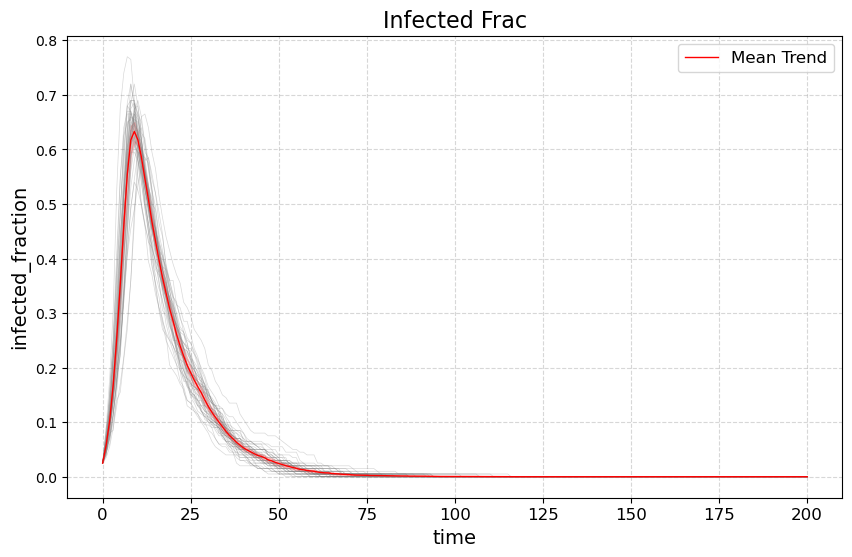

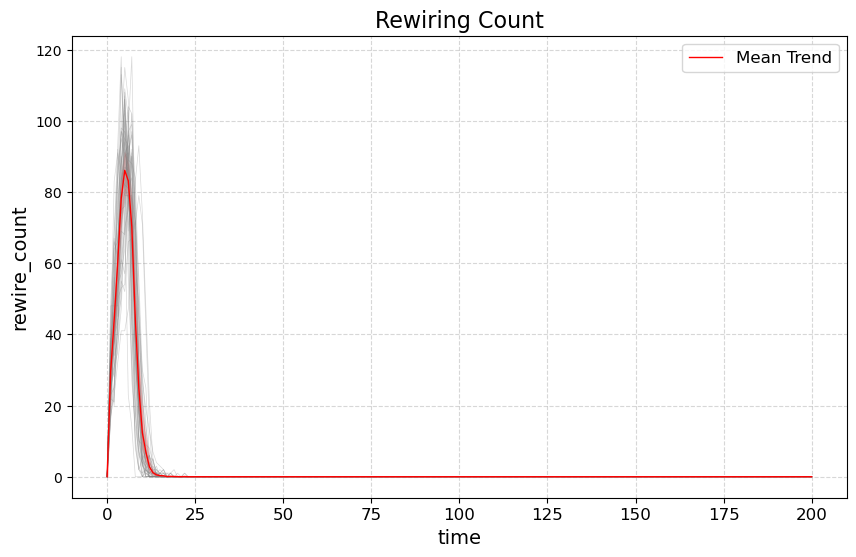

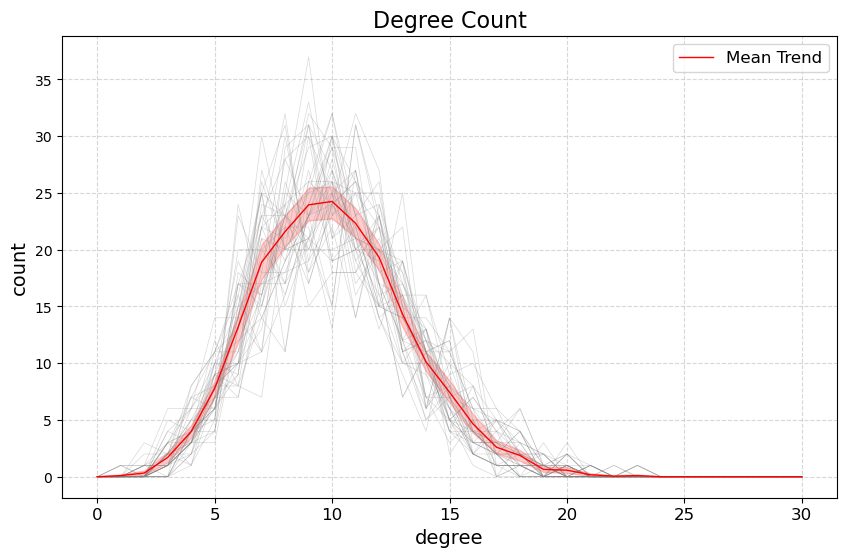

In [34]:
# Explanatory plot of one observed replicate

# Infected fraction
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.title('Infected Frac')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('infected_frac_obs.png')
# plt.show()

# Rewiring count
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.title('Rewiring Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('rewiring_count_obs.png')
# plt.show()

# Degree distribution
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.title('Degree Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('degree_count_obs.png')
# plt.show()

In [6]:
N_total = 100_000
quantile = 0.01

N_acc = int(N_total * quantile)
dim = 3
size = (N_acc, dim)
# We generated N_total and leave N
# N_total = int(N_acc / quantile)

In [7]:
# Prior sampler
def prior_sampler(N):
    alpha = np.random.uniform(0.05, 0.5, size = N)
    beta = np.random.uniform(0.02, 0.2, size = N)
    rho = np.random.uniform(0.0, 0.8, size = N)
    return np.column_stack((alpha, beta, rho))

In [ ]:
# Prior and Simulation
theta_proposals = prior_sampler(N_total)

Y_sim_all = []
for theta in tqdm(theta_proposals, desc='get ref table'):
    rng = np.random.default_rng(42)
    pre_y_sim = simulate(*theta, rng=rng)
    Y_sim_all.append(pre_y_sim)

# Save reference table
table = {'theta': theta_proposals, 'y': Y_sim_all}
with open('reference_table.pkl', 'wb') as f:
    pickle.dump(table, f)

get ref table:   0%|          | 0/100000 [00:00<?, ?it/s]

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\friya\AppData\Local\Temp\ipykernel_23936\951573831.py", line 23, in <module>
    pre_y_sim = simulate(*theta, rng=rng)
                ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\friya\AppData\Local\Temp\ipykernel_23936\2842168580.py", line None, in simulate
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\IPython\core\interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\IPython\core\ultratb.py", line 1435, in structured_traceback
    return FormattedTB.structured_traceb

In [ ]:
# Reference table saver - PARALLELIZED

N_acc = 10
dim = 3
size = (N_acc, dim)
quantile = 0.05
N_total = 100_000

# Checkpoint
chunk_size = 25_000

def prior_sampler(N):
    alpha = np.random.uniform(0.05, 0.5, size=N)
    beta = np.random.uniform(0.02, 0.2, size=N)
    rho = np.random.uniform(0.0, 0.8, size=N)
    return np.column_stack((alpha, beta, rho))

def worker(theta):
    rng = np.random.default_rng()
    return simulate(*theta, rng=rng)

theta_proposals = prior_sampler(N_total)
Y_sim_all = []

for i in range(0, N_total, chunk_size):
    chunk = theta_proposals[i : i + chunk_size]
    
    results = Parallel(n_jobs=4, backend="loky")(
        delayed(worker)(theta) for theta in tqdm(chunk, desc=f'Batch {i//chunk_size + 1}')
    )
    
    Y_sim_all.extend(results)
    
    checkpoint_table = {
        'theta': theta_proposals[:len(Y_sim_all)], 
        'y': Y_sim_all
    }
    with open(f'reference_table_checkpoint_{len(Y_sim_all)}.pkl', 'wb') as f:
        pickle.dump(checkpoint_table, f)

table = {'theta': theta_proposals, 'y': Y_sim_all}
with open('reference_table_final.pkl', 'wb') as f:
    pickle.dump(table, f)

Batch 1:   0%|          | 0/25000 [00:00<?, ?it/s]

Batch 2:   0%|          | 0/25000 [00:00<?, ?it/s]

Batch 3:   0%|          | 0/25000 [00:00<?, ?it/s]

Batch 4:   0%|          | 0/25000 [00:00<?, ?it/s]

### Explore summary stats choices

In [36]:
# Load saved ref table
with open('reference_table_final.pkl', 'rb') as f:
    ref_table = pickle.load(f)

theta = ref_table['theta']
y_sim = ref_table['y']

In [37]:
# Compute summary stat

def summary_stats_computation(y):
    infected_max = np.max(y[0])

    rewiring_max = np.max(y[1])
    
    degree_kl_div = degree_kl_divergence(y[2])

    return np.array([infected_max, rewiring_max, degree_kl_div])

summary_stats_sim = []
for y in y_sim:
    summary_stats_sim.append(summary_stats_computation(y))

In [38]:
# Now for observed data
summary_stats_obs = []

for id in range(40):
    infected_max = np.max(infected_obs[infected_obs['replicate_id'] == id]['infected_fraction'])

    rewiring_max = np.max(rewiring_obs[rewiring_obs['replicate_id'] == id]['rewire_count'])

    degree_kl_div = degree_kl_divergence(degree_obs[degree_obs['replicate_id'] == id]['count'].values)

    summary_stats_obs.append(np.array([infected_max, rewiring_max, degree_max]))

summary_stats_obs = np.array(summary_stats_obs)
y_obs = np.mean(summary_stats_obs, axis=0)
y_obs

array([ 0.657125, 98.125   , 26.      ])

In [39]:
# Filter reference table by Mahalanobis distance

# quantile for filteration
epsilon = 0.01

cov = np.cov(summary_stats_sim, rowvar=False)
if cov.ndim == 0: cov = np.array([[cov]])
VI = np.linalg.pinv(cov) # pinv for stability

diff = summary_stats_sim - y_obs
distances = np.sqrt(np.sum(np.dot(diff, VI) * diff, axis=1))

indices = np.argsort(distances)[:int(N_total*epsilon)]
theta_filtered = theta[indices]

# posterior mean of theta
theta_post = np.mean(theta_filtered, axis=0)
print(theta_post)

[0.1603122  0.0962008  0.67009522]


In [ ]:
# Compute summary stats using posterior mean theta
rng = np.random.default_rng()
y_sim_rejABC_explore = simulate(*theta_post, rng=rng)

c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

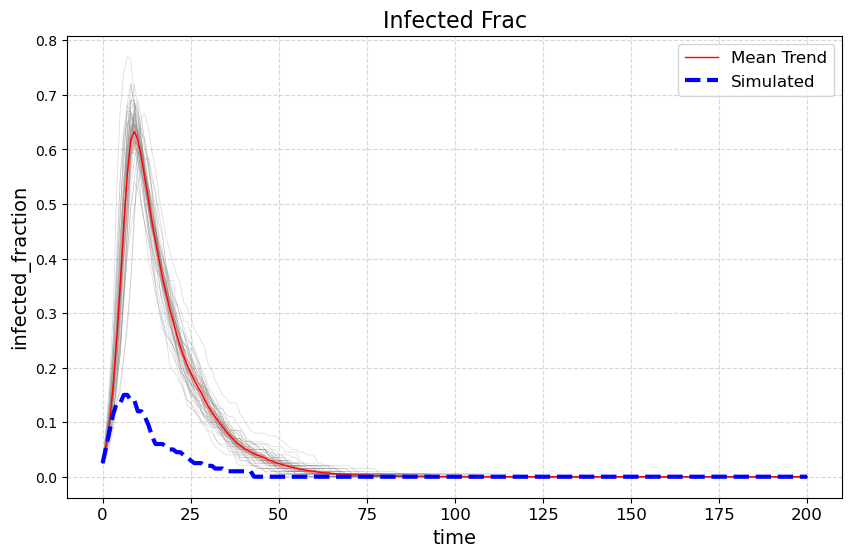

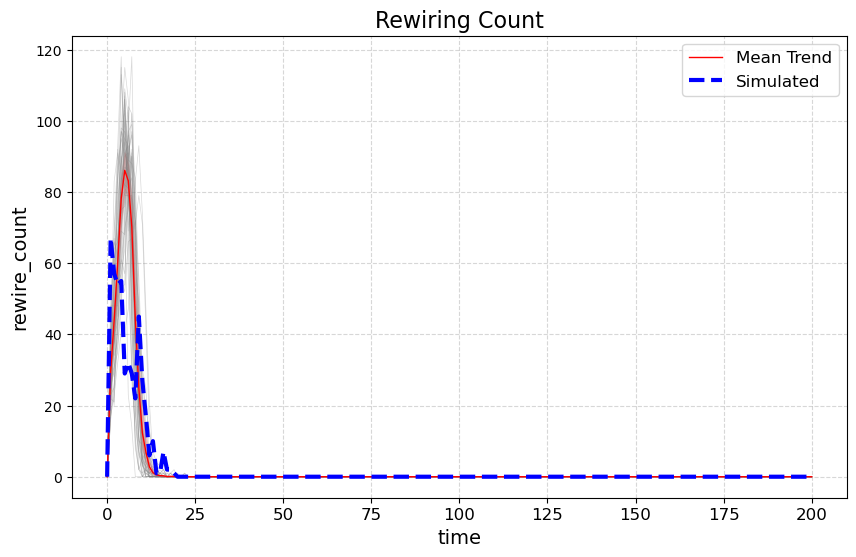

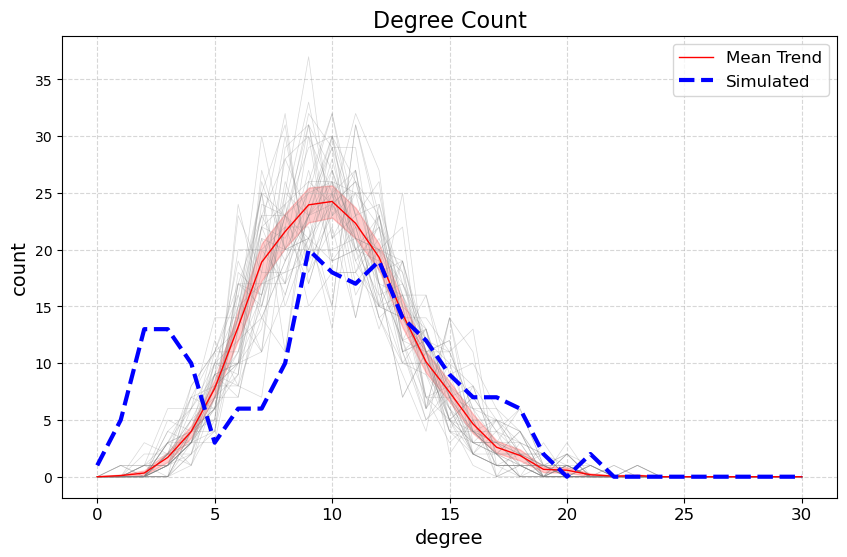

In [ ]:
# Posterior predictive check - rejection ABC
# Spaghetti plot

# Infected fraction
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_rejABC_explore[0], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Infected Frac')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('infected_frac_rejABC_explore.png')
# plt.show()

# Rewiring count
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_rejABC_explore[1], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Rewiring Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('rewiring_count_rejABC_explore.png')
# plt.show()

# Degree distribution
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_rejABC_explore[2], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Degree Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('degree_count_rejABC_explore.png')
# plt.show()

### Rejection ABC

In [40]:
# Load saved ref table
with open('reference_table_final.pkl', 'rb') as f:
    ref_table = pickle.load(f)

theta = ref_table['theta']
y_sim = ref_table['y']

In [41]:
# Compute summary stat

def summary_stats_computation(y):
    infected_max = np.max(y[0])
    infected_argmax = np.argmax(y[0])

    rewiring_max = np.max(y[1])
    rewiring_argmax = np.argmax(y[1])
    rewiring_total_count = np.sum(y[1])
    
    degree_kl_div = degree_kl_divergence(y[2])

    return np.array([infected_max, infected_argmax, rewiring_max, rewiring_argmax, rewiring_total_count, degree_kl_div])

summary_stats_sim = []
for y in y_sim:
    summary_stats_sim.append(summary_stats_computation(y))

In [42]:
# Now for observed data
summary_stats_obs = []

for id in range(40):
    infected_max = np.max(infected_obs[infected_obs['replicate_id'] == id]['infected_fraction'])
    infected_argmax = np.argmax(infected_obs[infected_obs['replicate_id'] == id]['infected_fraction'])

    rewiring_max = np.max(rewiring_obs[rewiring_obs['replicate_id'] == id]['rewire_count'])
    rewiring_argmax = np.argmax(rewiring_obs[rewiring_obs['replicate_id'] == id]['rewire_count'])
    rewiring_total_count = np.sum(rewiring_obs[rewiring_obs['replicate_id'] == id]['rewire_count'])

    degree_kl_div = degree_kl_divergence(degree_obs[degree_obs['replicate_id'] == id]['count'].values)

    summary_stats_obs.append(np.array([infected_max, infected_argmax, rewiring_max, rewiring_argmax, rewiring_total_count, degree_kl_div]))

summary_stats_obs = np.array(summary_stats_obs)
y_obs = np.mean(summary_stats_obs, axis=0)
y_obs

array([6.5712500e-01, 8.7500000e+00, 9.8125000e+01, 5.5000000e+00,
       5.4515000e+02, 6.0293937e-02])

In [45]:
# Filter reference table by Mahalanobis distance

# quantile for filteration
epsilon = 0.01

cov = np.cov(summary_stats_sim, rowvar=False)
if cov.ndim == 0: cov = np.array([[cov]])
VI = np.linalg.pinv(cov) # pinv for stability

diff = summary_stats_sim - y_obs
distances = np.sqrt(np.sum(np.dot(diff, VI) * diff, axis=1))

indices = np.argsort(distances)[:int(N_total*epsilon)]
theta_filtered = theta[indices]

# posterior mean of theta
theta_post = np.mean(theta_filtered, axis=0)
print(theta_post)

[0.18107177 0.09100338 0.31567744]


In [19]:
# Compute summary stats using posterior mean theta
rng = np.random.default_rng()
y_sim_rejABC = simulate(*theta_post, rng=rng)

c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

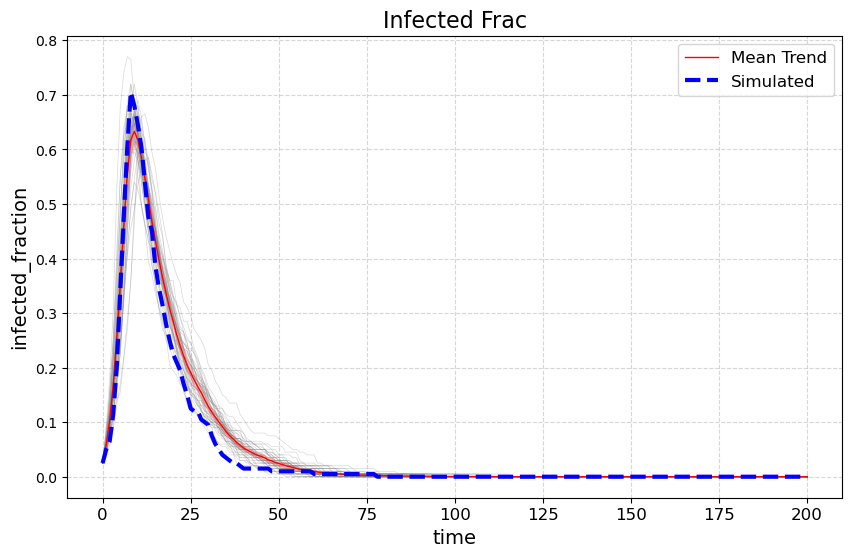

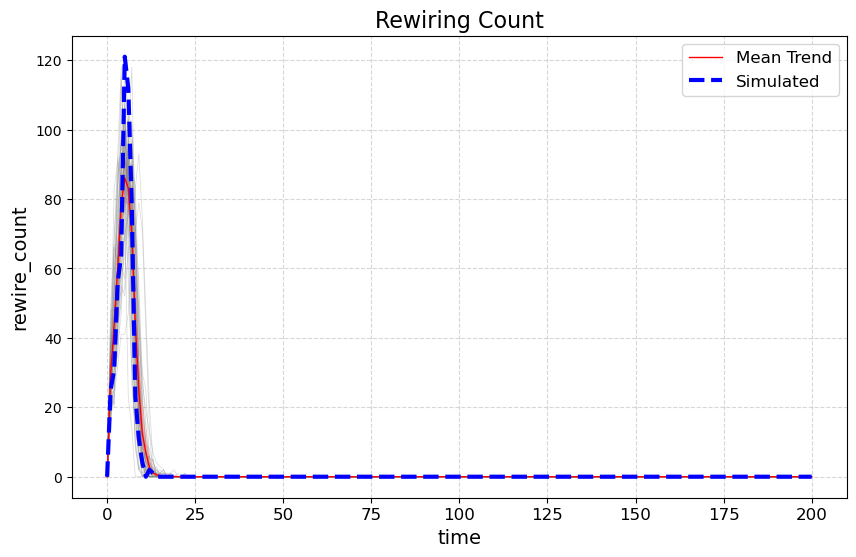

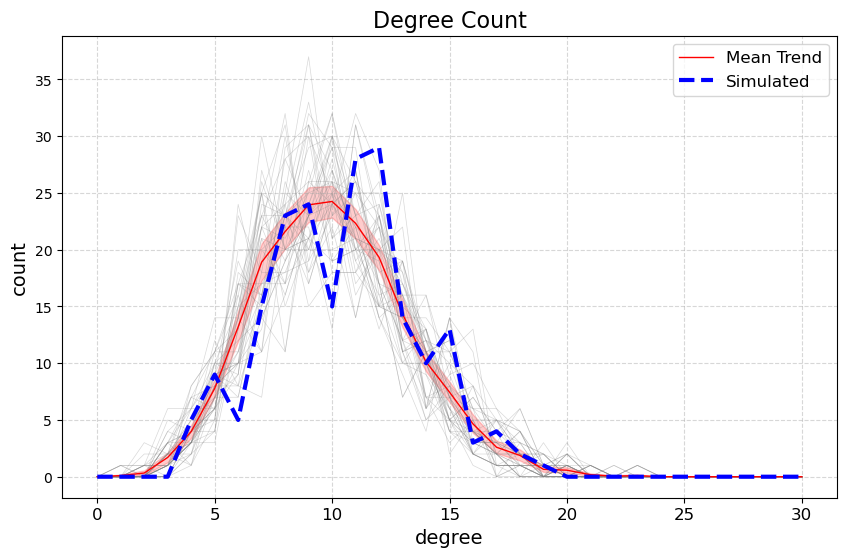

In [20]:
# Posterior predictive check - rejection ABC
# Spaghetti plot

# Infected fraction
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_rejABC[0], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Infected Frac')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('infected_frac_rejABC.png')
# plt.show()

# Rewiring count
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_rejABC[1], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Rewiring Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('rewiring_count_rejABC.png')
# plt.show()

# Degree distribution
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_rejABC[2], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Degree Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('degree_count_rejABC.png')
# plt.show()

In [ ]:
# Simulation-based calibration (SBC)
N_calibration = 500

# quantile for filtration
epsilon = 0.01

cov = np.cov(summary_stats_sim, rowvar=False)
if cov.ndim == 0: cov = np.array([[cov]])
VI = np.linalg.pinv(cov) # pinv for stability

all_ranks = []

for i in range(N_calibration):
    theta_true = prior_sampler(1)
    data_sim = simulate(*theta_true[0], rng=np.random.default_rng())
    summary_stat = summary_stats_computation(data_sim)

    # ABC
    diff = summary_stats_sim - summary_stat
    distances = np.sqrt(np.sum(np.dot(diff, VI) * diff, axis=1))

    indices = np.argsort(distances)[:int(N_total*epsilon)]
    theta_filtered = theta[indices]

    # Check rank for calibration test
    rank = np.sum(theta_filtered < theta_true, axis=0)
    all_ranks.append(rank)
    
    if (i+1) % (N_calibration//5) == 0:
        print(f"Iteration {i+1}/{N_calibration} complete.")

# Plot result
def plot_sbc_results(ranks, param_names=['beta', 'gamma', 'rho'], title='SBC Rank Histograms.png'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, name in enumerate(param_names):
        axes[i].hist(ranks[:, i], bins=15, density=True, alpha=0.7, edgecolor='black')
        axes[i].set_title(f"SBC Rank Histogram: {name}")

    # plt.savefig(title)
    plt.show()
plot_sbc_results(np.array(all_ranks), title='rejABC_SBC_0.05.png')

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\friya\AppData\Local\Temp\ipykernel_23176\1631978278.py", line 15, in <module>
    data_sim = simulate(*theta_true[0], rng=np.random.default_rng())
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\friya\AppData\Local\Temp\ipykernel_23176\2842168580.py", line None, in simulate
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\IPython\core\interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\IPython\core\ultratb.py", line 1435, in struct

### Advanced method
### SMC ABC

In [ ]:
# RUN PARALLEL SMC_ABC

from scipy.stats import multivariate_normal
import time
from tqdm.auto import tqdm

def _evaluate_candidate(candidate, observed_summary, VI, next_epsilon):
    """
    Helper function for parallel workers.
    Runs simulation and calculates distance for a single candidate.
    """
    # 1. Simulate
    # Note: simulate and summary_stats_computation must be defined in your environment
    s_sim = summary_stats_computation(simulate(*candidate, rng=np.random.default_rng()))
    
    # 2. Calculate Mahalanobis distance
    diff = s_sim - observed_summary
    dist = np.sqrt(np.dot(np.dot(diff, VI), diff))
    
    # 3. Return if accepted
    if dist < next_epsilon:
        return candidate, dist
    return None

def smc_abc_parallel(observed_summary, theta_table, stats_table, 
                     N_particles=1000, T_generations=5, 
                     alpha=0.5, initial_quantile=0.1, 
                     min_acceptance_rate=1e-5, max_attempts_per_gen=500000,
                     n_jobs=6):
    """
    Parallelized SMC ABC using joblib with N_jobs=6.
    """
    generations = []
    
    # Pre-compute Mahalanobis VI from reference table
    cov = np.cov(stats_table, rowvar=False)
    VI = np.linalg.pinv(cov)

    # --- Generation 0: Reference Table Extraction ---
    print("\n" + "="*50)
    print("GENERATION 0: INITIALIZING FROM REFERENCE TABLE")
    print("="*50)
    
    diff_0 = stats_table - observed_summary
    dist_0 = np.sqrt(np.sum(np.dot(diff_0, VI) * diff_0, axis=1))
    
    gen_0_epsilon = np.percentile(dist_0, initial_quantile * 100)
    indices_0 = np.where(dist_0 <= gen_0_epsilon)[0]

    if len(indices_0) >= N_particles:
        selected_indices = np.random.choice(indices_0, size=N_particles, replace=False)
    else:
        print(f"[Warning] Eligible particles ({len(indices_0)}) less than N_particles. Using top N.")
        selected_indices = np.argsort(dist_0)[:N_particles]
        gen_0_epsilon = dist_0[selected_indices[-1]]

    generations.append({
        'theta': theta_table[selected_indices], 
        'dist': dist_0[selected_indices], 
        'weights': np.ones(N_particles) / N_particles, 
        'epsilon': gen_0_epsilon
    })
    print(f"Gen 0 Complete. Initial Epsilon (Threshold): {gen_0_epsilon:.4f}\n")

    # --- Generation 1 to T ---
    for t in range(1, T_generations):
        prev_gen = generations[t-1]
        prev_theta = prev_gen['theta']
        prev_weights = prev_gen['weights']
        
        # Determine next threshold (Quantile-based)
        next_epsilon = np.percentile(prev_gen['dist'], alpha * 100)
        
        print("="*50)
        print(f"GENERATION {t} | TARGET EPSILON: {next_epsilon:.4f}")
        print("="*50)

        kernel_cov = 2 * np.cov(prev_theta, rowvar=False, aweights=prev_weights)
        
        new_theta, new_dist = [], []
        accepted = 0
        attempts = 0
        start_time = time.time()
        
        # Use a batch size that is a multiple of n_jobs for efficiency
        batch_size = n_jobs * 4 
        
        while accepted < N_particles:
            # 1. Prepare candidates (Prior check)
            candidates = []
            while len(candidates) < batch_size:
                idx = np.random.choice(N_particles, p=prev_weights)
                c = multivariate_normal.rvs(mean=prev_theta[idx], cov=kernel_cov)
                if np.all((c >= 0) & (c <= 1)):
                    candidates.append(c)
            
            # 2. Parallel simulation
            results = Parallel(n_jobs=n_jobs)(
                delayed(_evaluate_candidate)(c, observed_summary, VI, next_epsilon) 
                for c in candidates
            )
            
            attempts += batch_size
            
            # 3. Collect results
            for res in results:
                if res is not None:
                    new_theta.append(res[0])
                    new_dist.append(res[1])
                    accepted += 1
                    if accepted >= N_particles:
                        break
            
            # Briefing
            acc_rate = accepted / attempts
            elapsed = time.time() - start_time
            print(f"Gen {t} Progress: {accepted}/{N_particles} | Attempts: {attempts} | Acc Rate: {acc_rate:.2e} | {elapsed:.1f}s", end='\r')
            
            if attempts > 1000 and acc_rate < min_acceptance_rate:
                print(f"\n[ABORTED] Acceptance rate too low.")
                break
            if attempts >= max_attempts_per_gen:
                print(f"\n[ABORTED] Max attempts reached.")
                break
        
        if accepted < N_particles:
            break

        # Final Summary for Gen t
        print(f"\n\nGen {t} SUMMARY: Acc Rate {accepted/attempts:.4e} | Time {time.time()-start_time:.2f}s")

        # Weight Update (Vectorized density calculation)
        new_theta = np.array(new_theta)[:N_particles]
        new_dist = np.array(new_dist)[:N_particles]
        
        densities = np.array([
            np.sum(prev_weights * multivariate_normal.pdf(prev_theta, mean=p, cov=kernel_cov)) 
            for p in new_theta
        ])
        new_weights = 1.0 / densities
        new_weights /= np.sum(new_weights)
        
        generations.append({
            'theta': new_theta, 
            'dist': new_dist, 
            'weights': new_weights, 
            'epsilon': next_epsilon
        })
        print("-" * 50 + "\n")

    return generations

# Run with N_jobs
res = smc_abc_parallel(y_obs, theta, summary_stats_sim, 
                       N_particles=2500, T_generations=5, 
                       alpha=0.7, initial_quantile=0.03, n_jobs=6)

with open('SMC_ABC_res_2500.pkl', 'wb') as f:
    pickle.dump(res, f)


GENERATION 0: INITIALIZING FROM REFERENCE TABLE
Gen 0 Complete. Initial Epsilon (Threshold): 0.9272

GENERATION 1 | TARGET EPSILON: 0.8623
Gen 1 Progress: 2500/2500 | Attempts: 20712 | Acc Rate: 1.21e-01 | 2503.7s

Gen 1 SUMMARY: Acc Rate 1.2070e-01 | Time 2503.68s
--------------------------------------------------

GENERATION 2 | TARGET EPSILON: 0.7923
Gen 2 Progress: 2500/2500 | Attempts: 25248 | Acc Rate: 9.90e-02 | 3022.1s

Gen 2 SUMMARY: Acc Rate 9.9018e-02 | Time 3022.12s
--------------------------------------------------

GENERATION 3 | TARGET EPSILON: 0.7300
Gen 3 Progress: 2500/2500 | Attempts: 28512 | Acc Rate: 8.77e-02 | 3297.7s

Gen 3 SUMMARY: Acc Rate 8.7682e-02 | Time 3297.71s
--------------------------------------------------

GENERATION 4 | TARGET EPSILON: 0.6764
Gen 4 Progress: 2500/2500 | Attempts: 35328 | Acc Rate: 7.08e-02 | 4040.0s

Gen 4 SUMMARY: Acc Rate 7.0765e-02 | Time 4040.02s
--------------------------------------------------



In [46]:
# Load SMC ABC result
with open('SMC_ABC_res_2500.pkl', 'rb') as f:
    res_smcABC = pickle.load(f)

theta_smcABC = res_smcABC[-1]['theta']
weights_smcABC = res_smcABC[-1]['weights']

In [47]:
# We have to consider weights for SMC ABC

# effective sample size
ESS = 1 / np.sum(weights_smcABC**2)
ESS_percentage = ESS / len(weights_smcABC) * 100
print(ESS_percentage)

# posterior mean with weights
post_mean_smcABC = np.average(theta_smcABC, axis=0, weights=weights_smcABC)
print(post_mean_smcABC)

91.28739689496459
[0.17605841 0.08820584 0.31460234]


In [333]:
# Compute summary stats using posterior mean theta
rng = np.random.default_rng()
y_sim_smcABC = simulate(*post_mean_smcABC, rng=rng)

c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\friya\anaconda3\envs\py3_11\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future ver

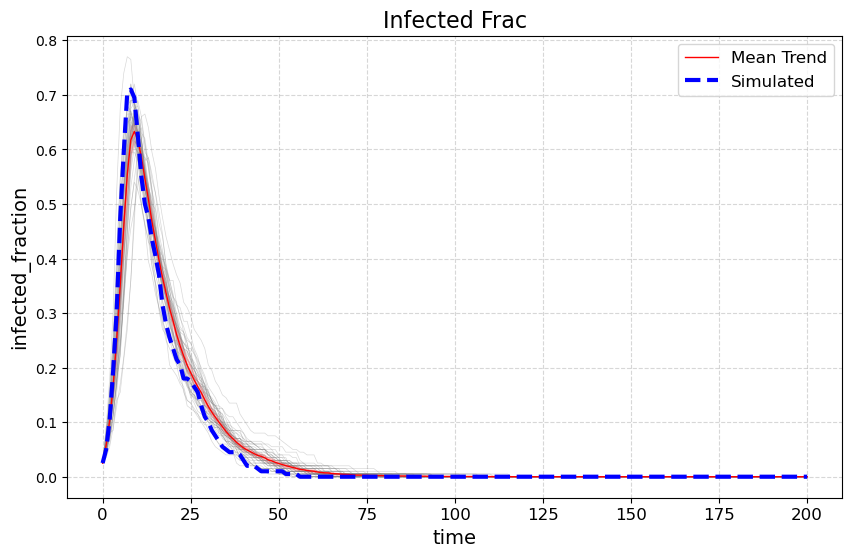

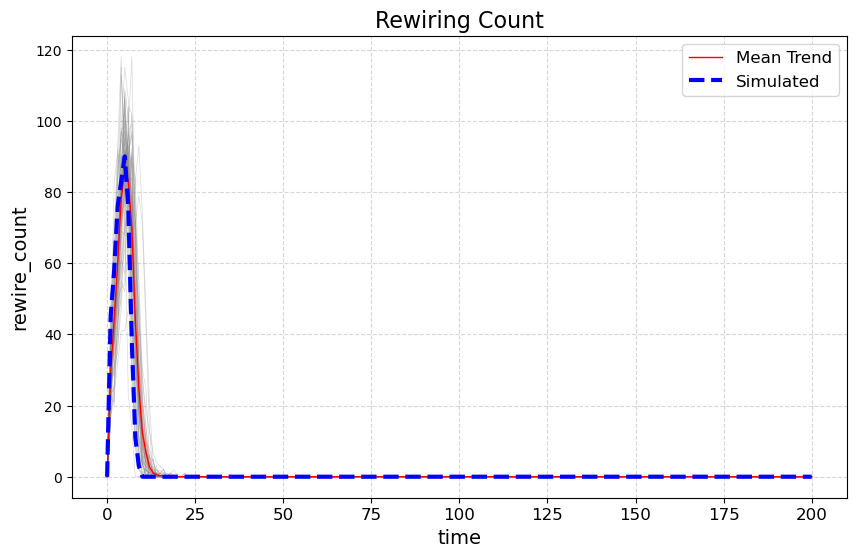

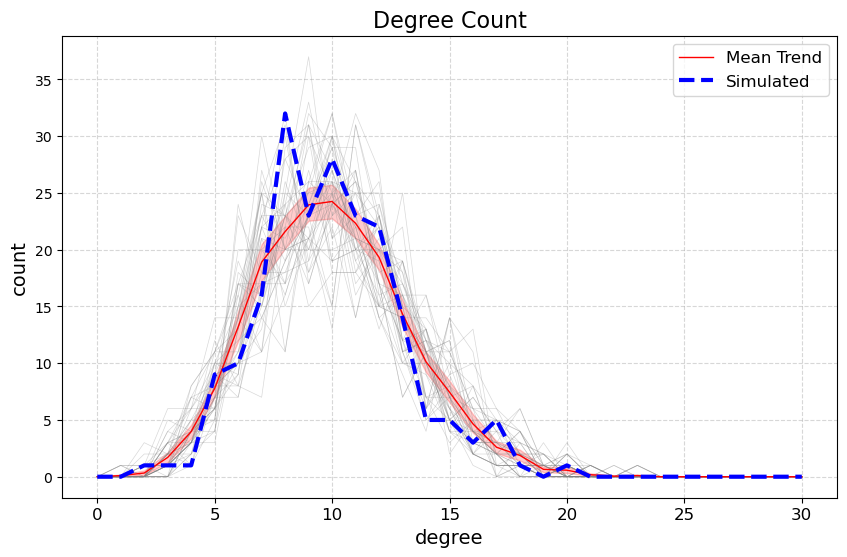

In [ ]:
# Posterior predictive check - SMC ABC
# Spaghetti plot

# Infected fraction
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=infected_obs, 
    x='time', 
    y='infected_fraction', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_smcABC[0], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Infected Frac')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('infected_frac_smcABC.png')
# plt.show()

# Rewiring count
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=rewiring_obs, 
    x='time', 
    y='rewire_count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_smcABC[1], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Rewiring Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('rewiring_count_smcABC.png')
# plt.show()

# Degree distribution
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    units='replicate_id', 
    estimator=None, 
    color='gray',
    alpha=0.3,
    linewidth=0.5
)
sns.lineplot(
    data=degree_obs, 
    x='degree', 
    y='count', 
    color='red', 
    linewidth=1, 
    label='Mean Trend'
)
plt.plot(
    y_sim_smcABC[2], 
    color='blue', 
    linewidth=3, 
    linestyle='--',
    label='Simulated'
)
plt.title('Degree Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig('degree_count_smcABC.png')
# plt.show()